# Infer polyspecificity half-maximal binding (PSR EC50) and calculate average differences in expression for individual clones (not libraries)

This notebook requires two input files (and the flow cytometry data):
- a run-list which specifies the antibody is being tested, along with the flow cytometry data directory
- a concentrations list which specifies the concentrations used (in -log10(mg/mL PSR)), along with 'well' assignments for looking up the flow cytometry data (we use a 96-well format for making these measurements, so the well numbers are automatically output when we export the flow cytometry fcs files to csvs)

For the polyspecificity EC50 component of this notebook we present two analyses (3-parameter and 4-parameter Hill function fits):
- the main analysis used for low-throughput validation in Tharp et al, 2026 uses the 3-parameter fit, which assumes the hill coefficient = 1 (one-site binding) 
- we include a 4-parameter fit (same as 3-parameter, but also fits the Hill coefficient) for comparison

It is probable that the polyspecificty reagent (pool of N-terminal biotinylated cytosolic human proteins, see Methods from Tharp et al, 2026) could elicit binding curves off the one-site binding expectation. However, we find that when we fit 4-parameter Hill functions the resulting Hill coefficient is often very close to 1 (and fits far from this are the result of poor fit quality - see antibody 5173, rep 2). Higher parameter fits also perform worse with our high-throughput PSR EC50 inference pipeline (data not shown, but our pipeline includes the option to perform a four-parameter fit for comparison), so we chose the 3-parameter fits for our high-throughput and low-throughput PSR EC50 inferences.
- see 'images' for the 3-parameter Hill fits and 'images_4p' for the 4-parameter Hill fits
- `analysis/polyspecificity_EC50_summary.csv` reports the averaged 3-paramter Hill fits for each of the individual clones tested and is used for low-throughput validation in Supplemental Figure 1

PSR titration curves use **mean** log10 PE at each concentration, with per-well **sample standard deviation** as the uncertainty in weighted least squares. Expression summarizes **median** log10 FITC per well, then averages those medians across the eight concentrations per replicate.

**Expression:** `analysis/omi_lt_expression-analysis.csv` reports the average difference in expression for each of the individual clones tested, and is used for low-throughput validation in Supplemental Figure 1.

## Imports and output directories

In [1]:
import os
import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.optimize

os.makedirs("images", exist_ok=True)
os.makedirs("images_4p", exist_ok=True)
os.makedirs("analysis", exist_ok=True)


In [2]:
#get run list
run_list = pd.read_csv('run-list.csv')
run_list = run_list.dropna(axis=0, how='any')  # drop columns with any NaN values
run_list['replicate'] = run_list['replicate'].astype(int)
run_list

,row,directory,shortname,antigen,replicate
0,A,flow_data/psr_expr_r1,2205,PSR,1
1,A,flow_data/psr_expr_r2,2205,PSR,2
2,B,flow_data/psr_expr_r1,6396,PSR,1
3,B,flow_data/psr_expr_r2,6396,PSR,2
4,C,flow_data/psr_expr_r1,5173,PSR,1
5,C,flow_data/psr_expr_r2,5173,PSR,2
6,D,flow_data/psr_expr_r1,6432,PSR,1
7,D,flow_data/psr_expr_r2,6432,PSR,2
8,E,flow_data/psr_expr_r1,4628,PSR,1
9,E,flow_data/psr_expr_r2,4628,PSR,2


In [3]:
#get PSR concentrations (in -log10(mg/mL PSR))
concentrations_list = pd.read_csv("concentrations-list.csv", index_col=0)
concentrations_list


,PSR
well column,
1,14.0
2,5.0
3,4.0
4,3.0
5,2.0
6,1.0
7,0.0
8,-0.5


## Load flow cytometry data

For each run, eight wells span the PSR concentration series. PE (PSR binding) and FITC (antibody expression) are floored at 100 raw fluorescence units before log10 transformation.

In [4]:
# define functions for assigning csv to each mutant

#pin raw values (not log-transformed yet) to a safe detection threshold within linear detector range (based on average CST settings provided by UCSF Flow Core)
PIN_FLOOR = 100.0 # raw fluorescence floor; log10 floor = 2

def get_PE_data(directory, sample_row, channel_pe="586_15 YG D-A", channel_expression="530_30 Blue C-A"):
    """Return one DataFrame per well (columns 1–8), with log PE and log expression."""
    wells = [sample_row + str(i) for i in range(1, 9)]
    dfs_by_well = []

    for well in wells:
        try:
            well_padded = well[0] + str(int(well[1])).zfill(2)
            file_pattern = os.path.join(
                directory,
                f"export_Specimen_001_{well}_{well_padded}_super_singles.csv",
            )
            matching_files = glob.glob(file_pattern)
            if not matching_files:
                print(f"Warning: No file found for well {well} in {directory}")
                continue

            df = pd.read_csv(matching_files[0])
            df["PE_floored"] = df[channel_pe].clip(lower=PIN_FLOOR)
            df["expression_floored"] = df[channel_expression].clip(lower=PIN_FLOOR)
            df["log_PE"] = np.log10(df["PE_floored"])
            df["log_expression"] = np.log10(df["expression_floored"])
            dfs_by_well.append(df)
        except Exception as e:
            print(f"Error loading {well}: {e}")
            continue

    return dfs_by_well


In [5]:
# get PE (PSR binding) and expression 
runs = []
for idx, row_data in run_list.iterrows():
    directory = row_data["directory"]
    sample_row = row_data["row"]
    print(f"Loading {sample_row} from {directory}...")
    run_data = get_PE_data(directory, sample_row)
    runs.append(run_data)

run_by_id = {run_id: runs[i] for i, run_id in enumerate(run_list.index)}
print(f"\nLoaded {len(runs)} runs with {len(runs[0])} concentrations each.")

Loading A from flow_data/psr_expr_r1...
Loading A from flow_data/psr_expr_r2...
Loading B from flow_data/psr_expr_r1...
Loading B from flow_data/psr_expr_r2...
Loading C from flow_data/psr_expr_r1...
Loading C from flow_data/psr_expr_r2...
Loading D from flow_data/psr_expr_r1...
Loading D from flow_data/psr_expr_r2...
Loading E from flow_data/psr_expr_r1...
Loading E from flow_data/psr_expr_r2...
Loading F from flow_data/psr_expr_r1...
Loading F from flow_data/psr_expr_r2...
Loading G from flow_data/psr_expr_r1...
Loading G from flow_data/psr_expr_r2...
Loading H from flow_data/psr_expr_r1...
Loading H from flow_data/psr_expr_r2...
Loading I from flow_data/psr_expr_r1...
Loading I from flow_data/psr_expr_r2...
Loading J from flow_data/psr_expr_r1...
Loading J from flow_data/psr_expr_r2...

Loaded 20 runs with 8 concentrations each.


## Three-parameter Hill fit (used for low-throughput validation in Tharp et al, 2026) 
- fixed Hill coefficient of 1 (identical to our isogenic Kd measurements)
- per concentration: mean log10(PE) per well; `curve_fit` uses sample stdev of log10(PE) within each well as `sigma`

https://elifesciences.org/articles/23156#s4

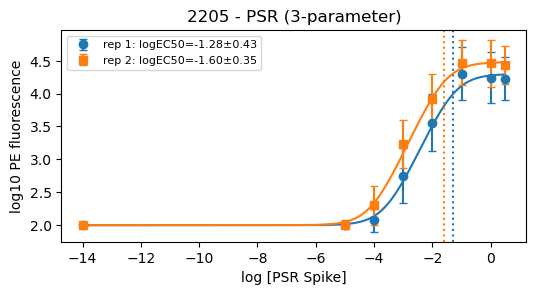

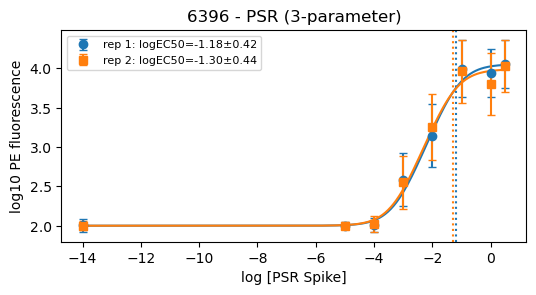

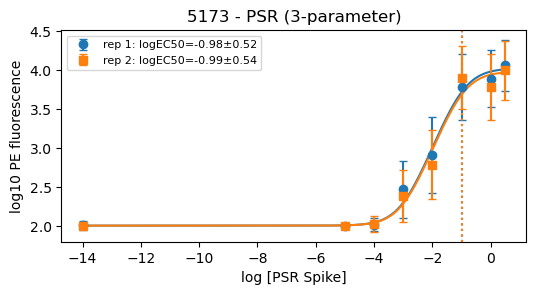

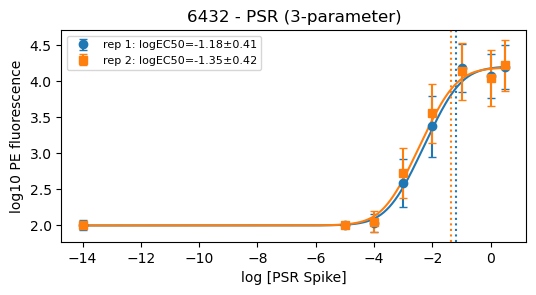

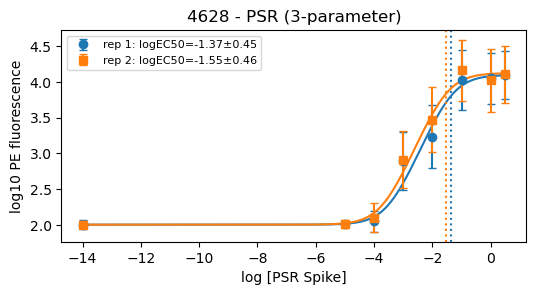

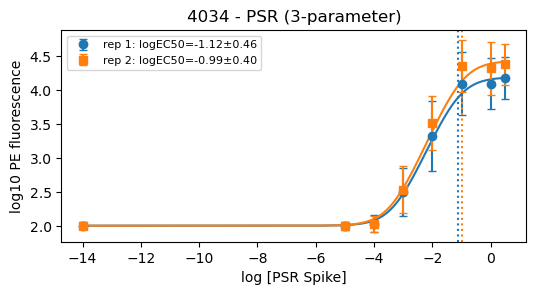

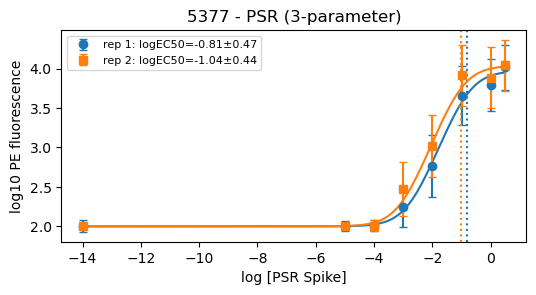

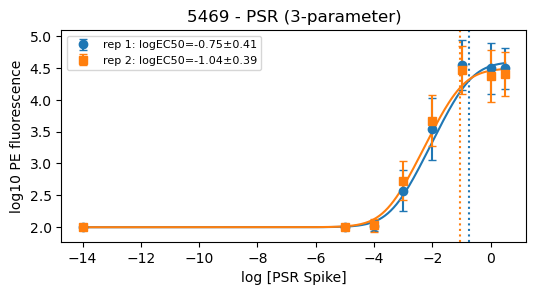

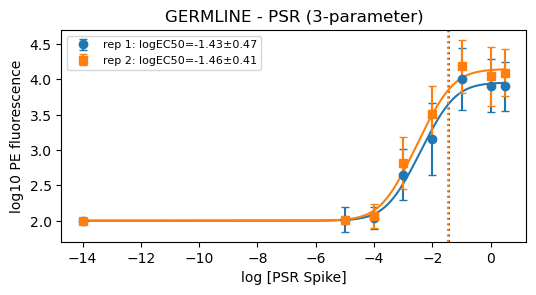

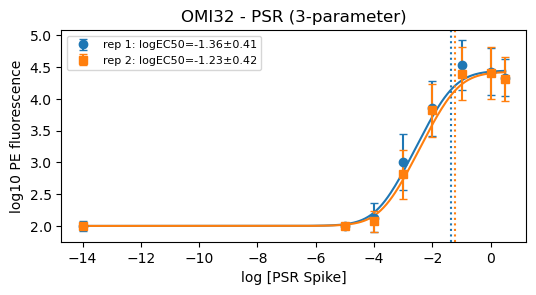

Saved 3-parameter fit figures to images/


In [6]:
def sigmoid(c, log_ec50, A, B):
    return np.log10(A * (10**np.float64(c) / ((10**np.float64(c)) + (10**np.float64(log_ec50)))) + B)
    
def rms(y, yfit):
    return np.sqrt(np.sum((y - yfit) ** 2))

run_list_3p = run_list.copy()
n_runs = run_list_3p.shape[0]
run_list_3p["log_EC50"] = np.nan
run_list_3p["log_EC50_err"] = np.nan
run_list_3p["hill_coefficient"] = np.nan
run_list_3p["hill_coefficient_err"] = np.nan
run_list_3p["amplitude_A"] = np.nan
run_list_3p["baseline_B"] = np.nan
run_list_3p["fit_quality_rmse"] = np.nan

rep_colors = {1: "#1f77b4", 2: "#ff7f0e", 3: "#2ca02c", 4: "#d62728", 5: "#9467bd"}
rep_markers = {1: "o", 2: "s", 3: "^", 4: "D", 5: "v"}

for shortname, grp in run_list_3p.groupby("shortname", sort=False):
    for antigen, grp2 in grp.groupby("antigen", sort=False):
        plt.figure(figsize=(6, 2.75))
        concs = (-concentrations_list[antigen]).copy()
        concs_plot = np.linspace(concs.min(), concs.max(), 300)

        for _, row in grp2.sort_values("replicate").iterrows():
            run_id = row.name
            run = run_by_id[run_id]
            rep = int(row["replicate"])

            mean_log_fluor = np.array([df["log_PE"].mean() for df in run])
            std_log_fluor = np.array(
                [np.nanstd(df["log_PE"].values, ddof=1) for df in run]
            )
            std_log_fluor_safe = np.where(
                (std_log_fluor == 0) | np.isnan(std_log_fluor),
                0.01,
                std_log_fluor,
            )

            popt, pcov = scipy.optimize.curve_fit(
                sigmoid,
                concs,
                mean_log_fluor,
                p0=[(-3), 10**4, 10**2],
                sigma=std_log_fluor_safe,
                absolute_sigma=True,
                bounds=[((-5), 300, 100), ((0.5), 10**6, 10**5)],
                maxfev=400000,
            )

            log_ec50 = popt[0]
            log_ec50_err = float(np.sqrt(pcov[0][0])) if pcov.shape == (3, 3) else np.nan
            fitted = sigmoid(concs, *popt)
            rmse = rms(mean_log_fluor, fitted)

            run_list_3p.loc[run_id, "log_EC50"] = log_ec50
            run_list_3p.loc[run_id, "log_EC50_err"] = log_ec50_err
            run_list_3p.loc[run_id, "amplitude_A"] = popt[1]
            run_list_3p.loc[run_id, "baseline_B"] = popt[2]
            run_list_3p.loc[run_id, "fit_quality_rmse"] = rmse

            color = rep_colors.get(rep, "black")
            marker = rep_markers.get(rep, "o")
            plt.errorbar(
                concs,
                mean_log_fluor,
                yerr=std_log_fluor_safe,
                fmt=marker,
                capsize=3,
                color=color,
                label=f"rep {rep}: logEC50={log_ec50:.2f}±{log_ec50_err:.2f}",
            )
            plt.plot(concs_plot, sigmoid(concs_plot, *popt), color=color)
            plt.axvline(log_ec50, linestyle=":", color=color)

        plt.xlabel(f"log [{antigen} Spike]")
        plt.ylabel("log10 PE fluorescence")
        plt.legend(fontsize=8, loc="upper left")
        plt.title(f"{shortname} - {antigen} (3-parameter)")
        plt.grid(False)
        out_png = f"{shortname}_{antigen}_replicates_3p.png"
        plt.savefig(os.path.join("images", out_png), format="png", bbox_inches="tight", dpi=150)
        plt.show()

print("Saved 3-parameter fit figures to images/")


### Save primary polyspecificity tables (3-parameter)
- full statistics for each replicate (`analysis/polyspecificity_EC50_results.csv`)
- averages of each replicate (with SEM) for low-throughput validation analysis in Supplemental Figure 1 (`analysis/polyspecificity_EC50_summary.csv`)

In [7]:
run_list_3p.to_csv("analysis/polyspecificity_EC50_results.csv")
print("Saved per-run results to analysis/polyspecificity_EC50_results.csv")

summary_rows = []
for shortname, grp in run_list_3p.groupby("shortname"):
    n_reps = len(grp)
    summary_rows.append(
        {
            "antibody": shortname,
            "antigen": grp["antigen"].iloc[0],
            "n_replicates": n_reps,
            "mean_log_EC50": grp["log_EC50"].mean(),
            "sem_log_EC50": grp["log_EC50"].std() / np.sqrt(n_reps) if n_reps > 1 else 0.0,
            "mean_hill_coefficient": np.nan,
            "sem_hill_coefficient": np.nan,
            "mean_amplitude_A": grp["amplitude_A"].mean(),
            "mean_baseline_B": grp["baseline_B"].mean(),
            "mean_fit_rmse": grp["fit_quality_rmse"].mean(),
        }
    )

summary_3p = pd.DataFrame(summary_rows)
summary_3p.to_csv("analysis/polyspecificity_EC50_summary.csv", index=False)
print("Saved antibody summary to analysis/polyspecificity_EC50_summary.csv")
summary_3p

Saved per-run results to analysis/polyspecificity_EC50_results.csv
Saved antibody summary to analysis/polyspecificity_EC50_summary.csv


,antibody,antigen,n_replicates,mean_log_EC50,sem_log_EC50,mean_hill_coefficient,sem_hill_coefficient,mean_amplitude_A,mean_baseline_B,mean_fit_rmse
0,2205,PSR,2,-1.439635,0.158201,NaN,NaN,24868.368968,100.00000,0.204258
1,4034,PSR,2,-1.052871,0.062639,NaN,NaN,21031.931596,100.00000,0.231461
2,4628,PSR,2,-1.459259,0.089462,NaN,NaN,12828.686218,100.00000,0.316002
3,5173,PSR,2,-0.985456,0.007173,NaN,NaN,9886.290734,100.00000,0.288838
4,5377,PSR,2,-0.920930,0.114315,NaN,NaN,10012.176262,100.00000,0.211650
5,5469,PSR,2,-0.892212,0.146733,NaN,NaN,35238.280049,100.00000,0.404903
6,6396,PSR,2,-1.242581,0.062022,NaN,NaN,10440.665799,100.00000,0.250868
7,6432,PSR,2,-1.266298,0.084048,NaN,NaN,15701.640577,100.00000,0.234882
8,GERMLINE,PSR,2,-1.443489,0.013342,NaN,NaN,11458.188423,100.02093,0.262254
9,OMI32,PSR,2,-1.291370,0.063862,NaN,NaN,27179.568685,100.00000,0.333246


## Four-parameter Hill fit
- same as 3-parameter but also fitting the Hill coefficient
- same per-well mean log10(PE) and within-well sample stdev for `sigma`

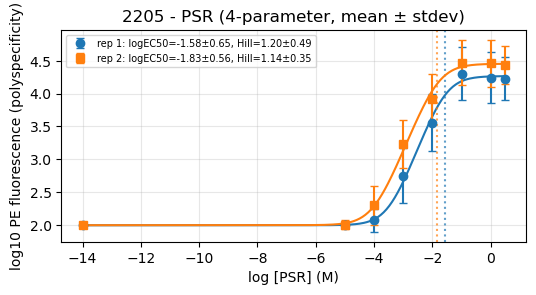

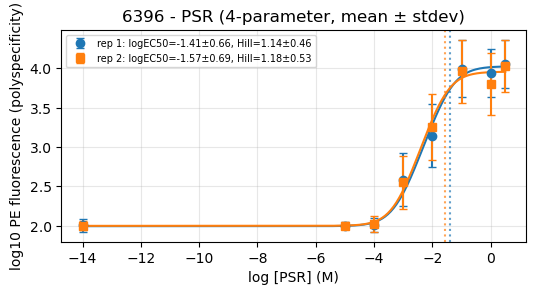

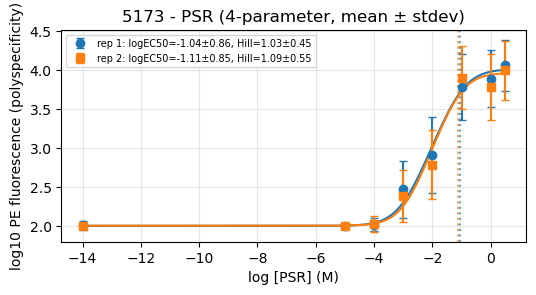

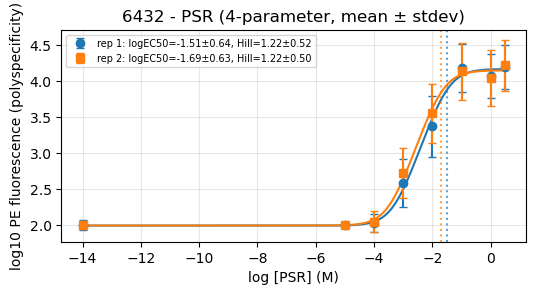

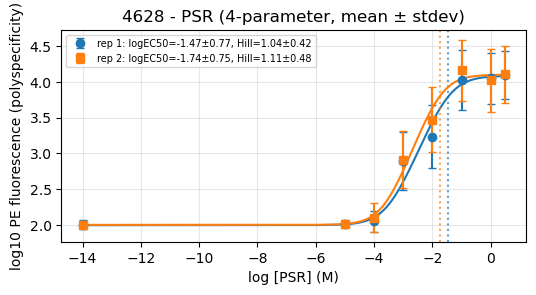

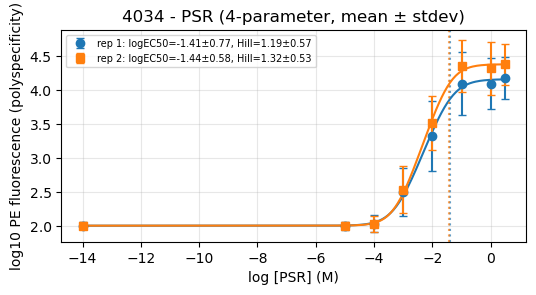

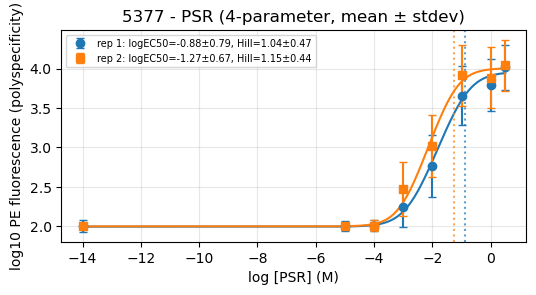

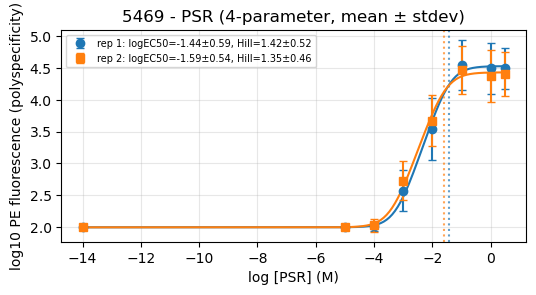

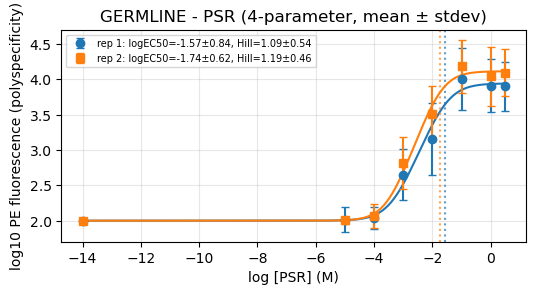

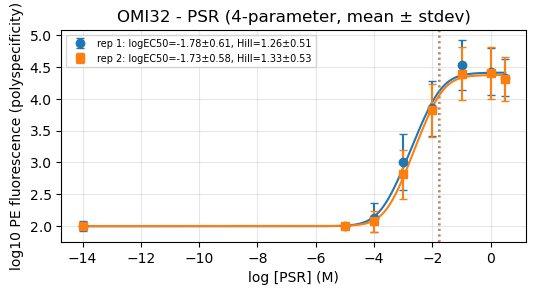

Saved 4-parameter fit figures to images_4p/


In [8]:
def fraction_bound_with_hill(log_conc, log_ec50, hill_coef, A, B):
    """log10 signal = log10(A * fraction + B) with fraction = C^n / (C^n + EC50^n)."""
    conc = 10 ** np.float64(log_conc)
    ec50 = 10 ** np.float64(log_ec50)
    fraction = conc**hill_coef / (conc**hill_coef + ec50**hill_coef)
    return np.log10(A * fraction + B)

run_list_4p = run_list.copy()
run_list_4p["log_EC50"] = np.nan
run_list_4p["log_EC50_err"] = np.nan
run_list_4p["hill_coefficient"] = np.nan
run_list_4p["hill_coefficient_err"] = np.nan
run_list_4p["amplitude_A"] = np.nan
run_list_4p["baseline_B"] = np.nan
run_list_4p["fit_quality_rmse"] = np.nan

for shortname, grp in run_list_4p.groupby("shortname", sort=False):
    for antigen, grp2 in grp.groupby("antigen", sort=False):
        plt.figure(figsize=(6, 2.75))
        concs = (-concentrations_list[antigen]).copy()
        concs_plot = np.linspace(concs.min(), concs.max(), 300)

        for _, row in grp2.sort_values("replicate").iterrows():
            run_id = row.name
            run = run_by_id[run_id]
            rep = int(row["replicate"])

            mean_log_fluor = np.array([df["log_PE"].mean() for df in run])
            std_log_fluor = np.array(
                [np.nanstd(df["log_PE"].values, ddof=1) for df in run]
            )

            y_data_min = mean_log_fluor.min()
            y_data_max = mean_log_fluor.max()
            fluor_min = 10**y_data_min
            fluor_max = 10**y_data_max
            initial_guess = [-2.0, 1.0, fluor_max - fluor_min, fluor_min]
            lower_bounds = [-14, 0.3, 1, 1]
            upper_bounds = [0.5, 5.0, 10**6, 10**5]

            std_log_fluor_safe = np.where(
                (std_log_fluor == 0) | np.isnan(std_log_fluor),
                0.01,
                std_log_fluor,
            )

            log_ec50 = np.nan
            log_ec50_err = np.nan
            hill_coef = np.nan
            hill_coef_err = np.nan
            popt = [np.nan] * 4

            try:
                popt, pcov = scipy.optimize.curve_fit(
                    fraction_bound_with_hill,
                    concs,
                    mean_log_fluor,
                    p0=initial_guess,
                    sigma=std_log_fluor_safe,
                    absolute_sigma=True,
                    bounds=(lower_bounds, upper_bounds),
                    maxfev=400000,
                )
                log_ec50, hill_coef, A, B = popt
                perr = np.sqrt(np.diag(pcov))
                log_ec50_err = perr[0]
                hill_coef_err = perr[1]
                fitted_values = fraction_bound_with_hill(concs, *popt)
                rmse = rms(mean_log_fluor, fitted_values)

                run_list_4p.loc[run_id, "log_EC50"] = log_ec50
                run_list_4p.loc[run_id, "log_EC50_err"] = log_ec50_err
                run_list_4p.loc[run_id, "hill_coefficient"] = hill_coef
                run_list_4p.loc[run_id, "hill_coefficient_err"] = hill_coef_err
                run_list_4p.loc[run_id, "amplitude_A"] = A
                run_list_4p.loc[run_id, "baseline_B"] = B
                run_list_4p.loc[run_id, "fit_quality_rmse"] = rmse
            except Exception as e:
                print(f"Fit failed for {shortname} rep {rep}: {e}")

            color = rep_colors.get(rep, "black")
            marker = rep_markers.get(rep, "o")
            plt.errorbar(
                concs,
                mean_log_fluor,
                yerr=std_log_fluor_safe,
                fmt=marker,
                capsize=3,
                color=color,
                label=(
                    f"rep {rep}: logEC50={log_ec50:.2f}±{log_ec50_err:.2f}, "
                    f"Hill={hill_coef:.2f}±{hill_coef_err:.2f}"
                ),
            )
            if not np.isnan(log_ec50):
                plt.plot(
                    concs_plot,
                    fraction_bound_with_hill(concs_plot, *popt),
                    color=color,
                    linewidth=1.5,
                )
                plt.axvline(log_ec50, linestyle=":", color=color, alpha=0.7)

        plt.xlabel(f"log [{antigen}] (M)")
        plt.ylabel("log10 PE fluorescence (polyspecificity)")
        plt.legend(fontsize=7, loc="upper left")
        plt.title(f"{shortname} - {antigen} (4-parameter, mean ± stdev)")
        plt.grid(True, alpha=0.3)
        out_png = f"{shortname}_{antigen}_EC50_FractionBound_4p.png"
        plt.savefig(os.path.join("images_4p", out_png), format="png", bbox_inches="tight", dpi=150)
        plt.show()

print("Saved 4-parameter fit figures to images_4p/")

### Save polyspecificity tables (4-parameter)
- full statistics for each replicate (`analysis/polyspecificity_EC50_results_4p.csv`)
- averages of each replicate (with SEM) (`analysis/polyspecificity_EC50_summary_4p.csv`)

In [9]:
run_list_4p.to_csv("analysis/polyspecificity_EC50_results_4p.csv")
print("Saved per-run results to analysis/polyspecificity_EC50_results_4p.csv")

summary_rows_4p = []
for shortname, grp in run_list_4p.groupby("shortname"):
    n_reps = len(grp)
    summary_rows_4p.append(
        {
            "antibody": shortname,
            "antigen": grp["antigen"].iloc[0],
            "n_replicates": n_reps,
            "mean_log_EC50": grp["log_EC50"].mean(),
            "sem_log_EC50": grp["log_EC50"].std() / np.sqrt(n_reps) if n_reps > 1 else 0.0,
            "mean_hill_coefficient": grp["hill_coefficient"].mean(),
            "sem_hill_coefficient": grp["hill_coefficient"].std() / np.sqrt(n_reps) if n_reps > 1 else 0.0,
            "mean_amplitude_A": grp["amplitude_A"].mean(),
            "mean_baseline_B": grp["baseline_B"].mean(),
            "mean_fit_rmse": grp["fit_quality_rmse"].mean(),
        }
    )

summary_4p = pd.DataFrame(summary_rows_4p)
summary_4p.to_csv("analysis/polyspecificity_EC50_summary_4p.csv", index=False)
print("Saved antibody summary to analysis/polyspecificity_EC50_summary_4p.csv")
summary_4p

Saved per-run results to analysis/polyspecificity_EC50_results_4p.csv
Saved antibody summary to analysis/polyspecificity_EC50_summary_4p.csv


,antibody,antigen,n_replicates,mean_log_EC50,sem_log_EC50,mean_hill_coefficient,sem_hill_coefficient,mean_amplitude_A,mean_baseline_B,mean_fit_rmse
0,2205,PSR,2,-1.705716,0.121638,1.168249,0.031779,23297.437445,99.871223,0.176969
1,4034,PSR,2,-1.423411,0.016263,1.259096,0.065653,19030.286657,99.992404,0.121457
2,4628,PSR,2,-1.601929,0.134184,1.074646,0.035075,12315.614158,98.901585,0.320461
3,5173,PSR,2,-1.073724,0.032691,1.055875,0.030613,9595.782525,99.589389,0.289007
4,5377,PSR,2,-1.076690,0.192438,1.095781,0.051486,9484.230975,99.627590,0.210639
5,5469,PSR,2,-1.517167,0.076789,1.386711,0.034779,30037.859512,99.692608,0.196133
6,6396,PSR,2,-1.492042,0.082925,1.157694,0.020910,9766.783634,99.143035,0.246560
7,6432,PSR,2,-1.601678,0.086841,1.221425,0.002231,14345.638458,99.579061,0.191736
8,GERMLINE,PSR,2,-1.650157,0.084986,1.140087,0.049538,10822.216403,100.026508,0.259167
9,OMI32,PSR,2,-1.756244,0.021380,1.293567,0.036508,24614.896009,99.159448,0.173831


## Surface expression and pairwise Δ expression

For each antibody, we take the **median** log\(_{10}\) FITC within each well at each concentration, then **average those eight well-level medians** per experimental replicate. Pairwise Δ expression vs each reference antibody is averaged across the two replicates. Output: **`omi_lt_expression-analysis.csv`**.

In [10]:
expression_data = []

for shortname, grp in run_list.groupby("shortname", sort=False):
    for antigen, grp2 in grp.groupby("antigen", sort=False):
        replicate_means = []
        replicate_sems = []

        for _, row in grp2.iterrows():
            run_id = row.name
            run = run_by_id[run_id]
            median_expressions_per_well = []
            for df in run:
                median_expressions_per_well.append(df["log_expression"].median())
            mean_of_medians = np.mean(median_expressions_per_well)
            sem_expression = np.std(median_expressions_per_well, ddof=1) / np.sqrt(
                len(median_expressions_per_well)
            )
            replicate_means.append(mean_of_medians)
            replicate_sems.append(sem_expression)

        expression_data.append(
            {
                "antibody": shortname,
                "antigen": antigen,
                "replicate_1_expression": replicate_means[0] if len(replicate_means) > 0 else np.nan,
                "replicate_2_expression": replicate_means[1] if len(replicate_means) > 1 else np.nan,
                "replicate_1_sem": replicate_sems[0] if len(replicate_sems) > 0 else np.nan,
                "replicate_2_sem": replicate_sems[1] if len(replicate_sems) > 1 else np.nan,
            }
        )

expression_df = pd.DataFrame(expression_data)
print("Per-antibody expression summary:")
expression_df

Per-antibody expression summary:


,antibody,antigen,replicate_1_expression,replicate_2_expression,replicate_1_sem,replicate_2_sem
0,2205,PSR,4.139161,4.254035,0.012394,0.013157
1,6396,PSR,4.297846,4.237990,0.017333,0.011827
2,5173,PSR,4.047430,4.083699,0.043098,0.032630
3,6432,PSR,4.236018,4.263617,0.020061,0.012490
4,4628,PSR,4.165602,4.179415,0.011712,0.014977
5,4034,PSR,4.204488,4.313919,0.022366,0.009417
6,5377,PSR,4.157090,4.129617,0.024790,0.049080
7,5469,PSR,4.173682,4.160402,0.034076,0.058159
8,GERMLINE,PSR,4.148735,4.200804,0.017146,0.012418
9,OMI32,PSR,4.224060,4.258799,0.024657,0.006479


### Pairwise deltas and export

In [11]:
antibodies = expression_df["antibody"].unique()

for ref_antibody in antibodies:
    ref_r1 = expression_df.loc[expression_df["antibody"] == ref_antibody, "replicate_1_expression"].values[0]
    expression_df[f"delta_ab_{ref_antibody}_rep1"] = (
        expression_df["replicate_1_expression"] - ref_r1
    )

for ref_antibody in antibodies:
    ref_r2 = expression_df.loc[expression_df["antibody"] == ref_antibody, "replicate_2_expression"].values[0]
    expression_df[f"delta_ab_{ref_antibody}_rep2"] = (
        expression_df["replicate_2_expression"] - ref_r2
    )

for ref_antibody in antibodies:
    c1, c2 = f"delta_ab_{ref_antibody}_rep1", f"delta_ab_{ref_antibody}_rep2"
    expression_df[f"mean_delta_ab_{ref_antibody}"] = (expression_df[c1] + expression_df[c2]) / 2.0
    expression_df[f"sem_delta_ab_{ref_antibody}"] = np.abs(expression_df[c1] - expression_df[c2]) / np.sqrt(2)

expression_df.to_csv("analysis/omi_lt_expression-analysis.csv", index=True)
print("Saved analysis/omi_lt_expression-analysis.csv")
expression_df

Saved analysis/omi_lt_expression-analysis.csv


,antibody,antigen,replicate_1_expression,replicate_2_expression,replicate_1_sem,replicate_2_sem,delta_ab_2205_rep1,delta_ab_6396_rep1,delta_ab_5173_rep1,delta_ab_6432_rep1,...,mean_delta_ab_4034,sem_delta_ab_4034,mean_delta_ab_5377,sem_delta_ab_5377,mean_delta_ab_5469,sem_delta_ab_5469,mean_delta_ab_GERMLINE,sem_delta_ab_GERMLINE,mean_delta_ab_OMI32,sem_delta_ab_OMI32
0,2205,PSR,4.139161,4.254035,0.012394,0.013157,0.000000,-0.158685,0.091731,-0.096857,...,-0.062605,0.003848,0.053244,0.100654,0.029556,0.090618,0.021829,0.044409,-0.044831,0.056664
1,6396,PSR,4.297846,4.237990,0.017333,0.011827,0.158685,0.000000,0.250416,0.061828,...,0.008714,0.119704,0.124564,0.022898,0.100876,0.032935,0.093149,0.079143,0.026488,0.066888
2,5173,PSR,4.047430,4.083699,0.043098,0.032630,-0.091731,-0.250416,0.000000,-0.188588,...,-0.193639,0.051734,-0.077789,0.045073,-0.101477,0.035036,-0.109204,0.011172,-0.175865,0.001082
3,6432,PSR,4.236018,4.263617,0.020061,0.012490,0.096857,-0.061828,0.188588,0.000000,...,-0.009386,0.057864,0.106464,0.038942,0.082775,0.028905,0.075049,0.017303,0.008388,0.005049
4,4628,PSR,4.165602,4.179415,0.011712,0.014977,0.026441,-0.132244,0.118172,-0.070416,...,-0.086695,0.067613,0.029155,0.029194,0.005466,0.019157,-0.002261,0.027051,-0.068921,0.014797
5,4034,PSR,4.204488,4.313919,0.022366,0.009417,0.065327,-0.093358,0.157058,-0.031530,...,0.000000,0.000000,0.115850,0.096806,0.092161,0.086770,0.084434,0.040561,0.017774,0.052816
6,5377,PSR,4.157090,4.129617,0.024790,0.049080,0.017929,-0.140756,0.109660,-0.078928,...,-0.115850,0.096806,0.000000,0.000000,-0.023689,0.010037,-0.031415,0.056245,-0.098076,0.043990
7,5469,PSR,4.173682,4.160402,0.034076,0.058159,0.034521,-0.124164,0.126252,-0.062336,...,-0.092161,0.086770,0.023689,0.010037,0.000000,0.000000,-0.007727,0.046209,-0.074387,0.033954
8,GERMLINE,PSR,4.148735,4.200804,0.017146,0.012418,0.009573,-0.149112,0.101304,-0.087284,...,-0.084434,0.040561,0.031415,0.056245,0.007727,0.046209,0.000000,0.000000,-0.066660,0.012255
9,OMI32,PSR,4.224060,4.258799,0.024657,0.006479,0.084899,-0.073786,0.176630,-0.011958,...,-0.017774,0.052816,0.098076,0.043990,0.074387,0.033954,0.066660,0.012255,0.000000,0.000000


## Run summary

In [12]:
print("=" * 60)
print("OUTPUT FILES")
print("=" * 60)
print("Primary polyspecificity (3-parameter):")
print("  analysis/polyspecificity_EC50_results.csv")
print("  analysis/polyspecificity_EC50_summary.csv")
print("  images/*.png")
print()
print("Secondary polyspecificity (4-parameter, _4p):")
print("  polyspecificity_EC50_results_4p.csv")
print("  polyspecificity_EC50_summary_4p.csv")
print("  images_4p/*.png")
print()
print("Expression:")
print("  omi_lt_expression-analysis.csv")
print("=" * 60)
print(f"Runs: {len(run_list)}, antibodies: {run_list['shortname'].nunique()}")


OUTPUT FILES
Primary polyspecificity (3-parameter):
  analysis/polyspecificity_EC50_results.csv
  analysis/polyspecificity_EC50_summary.csv
  images/*.png

Secondary polyspecificity (4-parameter, _4p):
  polyspecificity_EC50_results_4p.csv
  polyspecificity_EC50_summary_4p.csv
  images_4p/*.png

Expression:
  omi_lt_expression-analysis.csv
Runs: 20, antibodies: 10
